In [44]:
import numpy as np
from PIL import Image, ImageDraw, ImageFilter
import random
import os
import json
from tqdm import tqdm
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

print("✅ Librerías cargadas")

✅ Librerías cargadas


In [45]:
from google.colab import drive
drive.mount('/content/drive')

BASE          = '/content/drive/MyDrive/trazos'
DATASET_BASE  = os.path.join(BASE, 'dataset', 'fase3_v2_entrenamiento')

estructura = {
    'tuberias_fondos_reales'     : ['train', 'val', 'test'],
    'tuberias_fondos_con_ruido'  : ['train', 'val', 'test'],
}

for carpeta, splits in estructura.items():
    for split in splits:
        for sub in ['inputs', 'masks']:
            path = os.path.join(DATASET_BASE, carpeta, split, sub)
            os.makedirs(path, exist_ok=True)

print("✅ Estructura fase3_v2 creada")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Estructura fase3_v2 creada


In [46]:
def mostrar_estructura(base, nivel=0, max_nivel=5):
    try:
        items = sorted(os.listdir(base))
        for item in items:
            print('    ' * nivel + f'📁 {item}')
            ruta = os.path.join(base, item)
            if os.path.isdir(ruta):
                mostrar_estructura(ruta, nivel + 1, max_nivel)
    except:
        pass

mostrar_estructura(DATASET_BASE)

📁 tuberias_fondos_con_ruido
    📁 test
        📁 inputs
        📁 masks
    📁 train
        📁 inputs
        📁 masks
    📁 val
        📁 inputs
        📁 masks
📁 tuberias_fondos_reales
    📁 test
        📁 inputs
        📁 masks
    📁 train
        📁 inputs
        📁 masks
    📁 val
        📁 inputs
        📁 masks


In [47]:
IMG_SIZE   = 256
TRAIN_N    = 1000
VAL_N      = 200
TEST_N     = 200
BG_COLOR   = 0
LINE_COLOR = 255

def grosor_tuberia():
    # CAMBIO: rango más amplio — tuberías más finas también
    # En F3 original era 4-12, ahora 3-10
    # Las tuberías PVC reales son más delgadas relativamente
    return random.randint(3, 10)

def color_tuberia_realista():
    """
    CAMBIO: colores más claros y cercanos a PVC real.
    Tuberías grises claras sobre fondos claros
    simulando el bajo contraste de instalaciones reales.
    """
    paleta = [
        (195, 195, 195),   # gris claro PVC
        (185, 185, 185),   # gris medio claro
        (175, 170, 165),   # gris beige claro
        (190, 188, 183),   # gris cálido
        (200, 198, 195),   # casi blanco grisáceo
        (178, 175, 170),   # gris frío claro
        (183, 180, 178),   # gris neutro
    ]
    base = random.choice(paleta)
    return tuple(max(0, min(255, c + random.randint(-8, 8))) for c in base)

print("✅ Configuración base lista")

✅ Configuración base lista


In [48]:
def fondo_azulejo():
    """
    NUEVO: fondo con cuadrícula de azulejos.
    Este era el principal problema en tuberia 6.png —
    la cuadrícula se confundía con estructura válida.
    El modelo debe aprender a ignorar cuadrículas.
    """
    color_azulejo = random.randint(180, 230)
    color_junta   = random.randint(140, 170)
    tam_azulejo   = random.randint(20, 40)

    arr = np.ones((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8) * color_azulejo

    # Dibujar juntas horizontales y verticales
    for y in range(0, IMG_SIZE, tam_azulejo):
        arr[max(0,y-1):y+1, :] = color_junta
    for x in range(0, IMG_SIZE, tam_azulejo):
        arr[:, max(0,x-1):x+1] = color_junta

    # Variación suave de color en cada azulejo
    ruido = np.random.normal(0, 3, arr.shape).astype(np.int16)
    arr   = np.clip(arr.astype(np.int16) + ruido, 0, 255).astype(np.uint8)

    return Image.fromarray(arr)


def fondo_ladrillo():
    """
    NUEVO: fondo de pared de ladrillo.
    Presente en tuberia.png — ladrillo blanco/gris claro.
    Patrón de ladrillos con juntas oscuras.
    """
    color_ladrillo = random.randint(190, 230)
    color_junta    = random.randint(150, 175)
    alto_ladrillo  = random.randint(15, 25)
    ancho_ladrillo = random.randint(35, 55)

    arr = np.ones((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8) * color_ladrillo

    # Hileras de ladrillo con offset alternado
    y = 0
    fila = 0
    while y < IMG_SIZE:
        arr[max(0,y-1):y+1, :] = color_junta
        offset = ancho_ladrillo // 2 if fila % 2 == 1 else 0
        x = offset
        while x < IMG_SIZE:
            arr[y:y+alto_ladrillo, max(0,x-1):x+1] = color_junta
            x += ancho_ladrillo
        y    += alto_ladrillo
        fila += 1

    ruido = np.random.normal(0, 4, arr.shape).astype(np.int16)
    arr   = np.clip(arr.astype(np.int16) + ruido, 0, 255).astype(np.uint8)

    return Image.fromarray(arr)


def fondo_concreto_rugoso():
    """
    NUEVO: concreto con textura rugosa y manchas.
    Presente en tuberia 7.png — pared de concreto gris.
    Más agresivo que el fondo liso de F3 original.
    """
    color_base = random.randint(100, 160)
    arr = np.ones((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32) * color_base

    # Textura rugosa con ruido fuerte
    ruido = np.random.normal(0, random.uniform(8, 18), arr.shape)
    arr   = np.clip(arr + ruido, 0, 255)

    img  = Image.fromarray(arr.astype(np.uint8))
    draw = ImageDraw.Draw(img)

    # Manchas de humedad
    n_manchas = random.randint(2, 6)
    for _ in range(n_manchas):
        x  = random.randint(0, IMG_SIZE)
        y  = random.randint(0, IMG_SIZE)
        rx = random.randint(15, 60)
        ry = random.randint(10, 40)
        intensidad   = random.randint(-25, 15)
        color_mancha = tuple(
            max(0, min(255, color_base + intensidad))
            for _ in range(3)
        )
        draw.ellipse([(x-rx,y-ry),(x+rx,y+ry)], fill=color_mancha)

    return img


def fondo_mixto():
    """
    NUEVO: combinación de texturas en la misma imagen.
    Simula instalaciones donde hay distintos materiales
    en la misma pared — muy común en construcción real.
    """
    tipo = random.choice(['azulejo', 'ladrillo', 'concreto'])
    if tipo == 'azulejo':
        return fondo_azulejo()
    elif tipo == 'ladrillo':
        return fondo_ladrillo()
    else:
        return fondo_concreto_rugoso()


print("✅ Generadores de fondos realistas listos")
print("   Fondos disponibles: azulejo, ladrillo, concreto rugoso, mixto")

✅ Generadores de fondos realistas listos
   Fondos disponibles: azulejo, ladrillo, concreto rugoso, mixto


In [49]:
def dibujar_tramo(draw_img, draw_mask, x0, y0, x1, y1, grosor, color):
    draw_img .line([(x0,y0),(x1,y1)], fill=color,      width=grosor)
    draw_mask.line([(x0,y0),(x1,y1)], fill=LINE_COLOR,  width=2)

def dibujar_sombra(draw_img, x0, y0, x1, y1, grosor):
    offset = grosor // 2 + 2
    # CAMBIO: sombra más sutil — gris oscuro en vez de negro
    # En F3 original era (15, 15, 15) — casi negro
    # Ahora (60, 60, 60) — gris oscuro más realista
    color_sombra = (60, 60, 60)
    draw_img.line(
        [(x0+offset, y0+offset),(x1+offset, y1+offset)],
        fill=color_sombra,
        width=grosor + 2
    )

def dibujar_abrazadera(draw_img, x, y, grosor):
    ancho = grosor + 6
    alto  = grosor + 4
    draw_img.rectangle([
        (x - ancho//2, y - alto//2),
        (x + ancho//2, y + alto//2)
    ], outline=(80, 80, 80), width=2)

def generar_tramo_recto(draw_img, draw_mask):
    grosor = grosor_tuberia()
    color  = color_tuberia_realista()
    orient = random.choice(['horizontal', 'vertical'])
    if orient == 'horizontal':
        y  = random.randint(30, IMG_SIZE - 30)
        x0 = random.randint(10, 60)
        x1 = random.randint(IMG_SIZE - 60, IMG_SIZE - 10)
        dibujar_sombra(draw_img, x0, y, x1, y, grosor)
        dibujar_tramo(draw_img, draw_mask, x0, y, x1, y, grosor, color)
        for ax in range(x0 + 30, x1 - 30, random.randint(40, 70)):
            if random.random() > 0.4:
                dibujar_abrazadera(draw_img, ax, y, grosor)
    else:
        x  = random.randint(30, IMG_SIZE - 30)
        y0 = random.randint(10, 60)
        y1 = random.randint(IMG_SIZE - 60, IMG_SIZE - 10)
        dibujar_sombra(draw_img, x, y0, x, y1, grosor)
        dibujar_tramo(draw_img, draw_mask, x, y0, x, y1, grosor, color)
        for ay in range(y0 + 30, y1 - 30, random.randint(40, 70)):
            if random.random() > 0.4:
                dibujar_abrazadera(draw_img, x, ay, grosor)

def generar_codo(draw_img, draw_mask):
    grosor = grosor_tuberia()
    color  = color_tuberia_realista()
    cx = random.randint(60, IMG_SIZE - 60)
    cy = random.randint(60, IMG_SIZE - 60)
    tipo = random.choice(['TL', 'TR', 'BL', 'BR'])
    if tipo == 'TL':
        x0, y0 = cx - random.randint(40, 90), cy
        x1, y1 = cx, cy - random.randint(40, 90)
    elif tipo == 'TR':
        x0, y0 = cx + random.randint(40, 90), cy
        x1, y1 = cx, cy - random.randint(40, 90)
    elif tipo == 'BL':
        x0, y0 = cx - random.randint(40, 90), cy
        x1, y1 = cx, cy + random.randint(40, 90)
    else:
        x0, y0 = cx + random.randint(40, 90), cy
        x1, y1 = cx, cy + random.randint(40, 90)
    dibujar_sombra(draw_img, x0, cy, cx, cy, grosor)
    dibujar_sombra(draw_img, cx, cy, cx, y1, grosor)
    dibujar_tramo(draw_img, draw_mask, x0, cy, cx, cy, grosor, color)
    dibujar_tramo(draw_img, draw_mask, cx, cy, cx, y1, grosor, color)

def generar_conexion_T(draw_img, draw_mask):
    grosor = grosor_tuberia()
    color  = color_tuberia_realista()
    cx = random.randint(60, IMG_SIZE - 60)
    cy = random.randint(60, IMG_SIZE - 60)
    orient = random.choice(['horizontal', 'vertical'])
    if orient == 'horizontal':
        x0 = cx - random.randint(40, 80)
        x1 = cx + random.randint(40, 80)
        dibujar_sombra(draw_img, x0, cy, x1, cy, grosor)
        dibujar_tramo(draw_img, draw_mask, x0, cy, x1, cy, grosor, color)
        dy = cy + random.randint(30, 70) * random.choice([-1, 1])
        dibujar_sombra(draw_img, cx, cy, cx, dy, grosor)
        dibujar_tramo(draw_img, draw_mask, cx, cy, cx, dy, grosor, color)
    else:
        y0 = cy - random.randint(40, 80)
        y1 = cy + random.randint(40, 80)
        dibujar_sombra(draw_img, cx, y0, cx, y1, grosor)
        dibujar_tramo(draw_img, draw_mask, cx, y0, cx, y1, grosor, color)
        dx = cx + random.randint(30, 70) * random.choice([-1, 1])
        dibujar_sombra(draw_img, cx, cy, dx, cy, grosor)
        dibujar_tramo(draw_img, draw_mask, cx, cy, dx, cy, grosor, color)

def generar_conexion_cruz(draw_img, draw_mask):
    grosor  = grosor_tuberia()
    color   = color_tuberia_realista()
    cx      = random.randint(70, IMG_SIZE - 70)
    cy      = random.randint(70, IMG_SIZE - 70)
    largo_h = random.randint(50, 90)
    largo_v = random.randint(50, 90)
    dibujar_sombra(draw_img, cx-largo_h, cy, cx+largo_h, cy, grosor)
    dibujar_tramo(draw_img, draw_mask, cx-largo_h, cy, cx+largo_h, cy, grosor, color)
    dibujar_sombra(draw_img, cx, cy-largo_v, cx, cy+largo_v, grosor)
    dibujar_tramo(draw_img, draw_mask, cx, cy-largo_v, cx, cy+largo_v, grosor, color)

def generar_red_tuberias(draw_img, draw_mask):
    grosor = grosor_tuberia()
    color  = color_tuberia_realista()
    x = random.randint(30, IMG_SIZE - 30)
    y = random.randint(30, 80)
    for _ in range(random.randint(3, 5)):
        orient = random.choice(['horizontal', 'vertical'])
        largo  = random.randint(40, 100)
        if orient == 'horizontal':
            nx = max(10, min(IMG_SIZE-10, x + largo * random.choice([-1,1])))
            dibujar_sombra(draw_img, x, y, nx, y, grosor)
            dibujar_tramo(draw_img, draw_mask, x, y, nx, y, grosor, color)
            x = nx
        else:
            ny = max(10, min(IMG_SIZE-10, y + largo * random.choice([-1,1])))
            dibujar_sombra(draw_img, x, y, x, ny, grosor)
            dibujar_tramo(draw_img, draw_mask, x, y, x, ny, grosor, color)
            y = ny

print("✅ Funciones de tubería listas")

✅ Funciones de tubería listas


In [50]:
SUBFASE  = 'tuberias_fondos_reales'
FASE_DIR = os.path.join(DATASET_BASE, SUBFASE)

random.seed(42)
np.random.seed(42)

def generar_imagen_y_mask():
    """
    CAMBIO PRINCIPAL vs F3 original:
    - Fondo ahora es azulejo, ladrillo o concreto rugoso
    - Color de tuberías más cercano al PVC real
    - Grosor ligeramente reducido
    Todo lo demás igual — mismos elementos estructurales.
    """
    # NUEVO: fondo realista en vez de gris uniforme
    img  = fondo_mixto()
    mask = Image.new('L', (IMG_SIZE, IMG_SIZE), color=BG_COLOR)

    draw_img  = ImageDraw.Draw(img)
    draw_mask = ImageDraw.Draw(mask)

    elementos = random.choices(
        ['tramo', 'codo', 'conexion_T', 'cruz', 'red'],
        weights=[3, 3, 2, 1, 2],
        k=random.randint(1, 3)
    )

    for elem in elementos:
        if elem == 'tramo':
            generar_tramo_recto(draw_img, draw_mask)
        elif elem == 'codo':
            generar_codo(draw_img, draw_mask)
        elif elem == 'conexion_T':
            generar_conexion_T(draw_img, draw_mask)
        elif elem == 'cruz':
            generar_conexion_cruz(draw_img, draw_mask)
        elif elem == 'red':
            generar_red_tuberias(draw_img, draw_mask)

    return img, mask


def guardar_split(split, cantidad):
    dir_input = os.path.join(FASE_DIR, split, 'inputs')
    dir_mask  = os.path.join(FASE_DIR, split, 'masks')
    for i in tqdm(range(cantidad), desc=f'  {split}'):
        img, mask = generar_imagen_y_mask()
        nombre = f'tuberia_real_{split}_{i:04d}'
        img .save(os.path.join(dir_input, f'{nombre}.png'))
        mask.save(os.path.join(dir_mask,  f'{nombre}.png'))

print('🚀 Generando tuberías con fondos realistas...')
guardar_split('train', TRAIN_N)
guardar_split('val',   VAL_N)
guardar_split('test',  TEST_N)
print('✅ Tuberías con fondos realistas listas')

🚀 Generando tuberías con fondos realistas...


  test: 100%|██████████| 200/200 [00:13<00:00, 14.91it/s]

✅ Tuberías con fondos realistas listas


In [51]:
SUBFASE  = 'tuberias_fondos_con_ruido'
FASE_DIR = os.path.join(DATASET_BASE, SUBFASE)

random.seed(99)
np.random.seed(99)

def agregar_tubo_fondo_oscuro(draw_img):
    """
    CAMBIO: tubos de fondo ahora son más oscuros
    para simular tuberías en segundo plano en
    instalaciones reales con poco contraste.
    """
    orient = random.choice(['horizontal', 'vertical'])
    grosor = random.randint(2, 5)
    color  = tuple(random.randint(60, 110) for _ in range(3))
    if orient == 'horizontal':
        y = random.randint(10, IMG_SIZE - 10)
        draw_img.line([(0,y),(IMG_SIZE,y)], fill=color, width=grosor)
    else:
        x = random.randint(10, IMG_SIZE - 10)
        draw_img.line([(x,0),(x,IMG_SIZE)], fill=color, width=grosor)

def agregar_iluminacion_lateral(img):
    arr  = np.array(img).astype(np.float32)
    lado = random.choice(['izquierda', 'derecha', 'arriba', 'abajo'])
    fuerte = random.uniform(1.1, 1.3)
    debil  = random.uniform(0.6, 0.85)
    if lado == 'izquierda':
        grad   = np.linspace(fuerte, debil, IMG_SIZE)
        factor = np.tile(grad, (IMG_SIZE, 1))
    elif lado == 'derecha':
        grad   = np.linspace(debil, fuerte, IMG_SIZE)
        factor = np.tile(grad, (IMG_SIZE, 1))
    elif lado == 'arriba':
        grad   = np.linspace(fuerte, debil, IMG_SIZE)
        factor = np.tile(grad, (IMG_SIZE, 1)).T
    else:
        grad   = np.linspace(debil, fuerte, IMG_SIZE)
        factor = np.tile(grad, (IMG_SIZE, 1)).T
    arr = arr * factor[:, :, np.newaxis]
    return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))

def agregar_ruido_gaussiano(img, intensidad_max=20):
    arr   = np.array(img).astype(np.float32)
    ruido = np.random.normal(0, random.uniform(5, intensidad_max), arr.shape)
    return Image.fromarray(np.clip(arr + ruido, 0, 255).astype(np.uint8))


def generar_imagen_y_mask_ruido():
    """
    CAMBIO PRINCIPAL vs F3 original:
    - Fondo realista (azulejo/ladrillo/concreto) + ruido encima
    - La cuadrícula del azulejo queda con blur y variación
      para que sea más difícil de distinguir de estructura
    - Tuberías de bajo contraste con iluminación variable
    La mask sigue siendo perfecta — solo la imagen tiene ruido.
    """
    img  = fondo_mixto()
    mask = Image.new('L', (IMG_SIZE, IMG_SIZE), color=BG_COLOR)

    draw_img  = ImageDraw.Draw(img)
    draw_mask = ImageDraw.Draw(mask)

    # Tubo de fondo opcional
    if random.random() > 0.4:
        agregar_tubo_fondo_oscuro(draw_img)

    # Elementos principales
    elementos = random.choices(
        ['tramo', 'codo', 'conexion_T', 'cruz', 'red'],
        weights=[3, 3, 2, 1, 2],
        k=random.randint(1, 3)
    )

    for elem in elementos:
        if elem == 'tramo':
            generar_tramo_recto(draw_img, draw_mask)
        elif elem == 'codo':
            generar_codo(draw_img, draw_mask)
        elif elem == 'conexion_T':
            generar_conexion_T(draw_img, draw_mask)
        elif elem == 'cruz':
            generar_conexion_cruz(draw_img, draw_mask)
        elif elem == 'red':
            generar_red_tuberias(draw_img, draw_mask)

    # Ruido encima del fondo realista
    img = agregar_iluminacion_lateral(img)
    img = agregar_ruido_gaussiano(img)
    img = img.filter(ImageFilter.GaussianBlur(
        radius=random.uniform(0.3, 0.8)
    ))

    return img, mask


def guardar_split_ruido(split, cantidad):
    dir_input = os.path.join(FASE_DIR, split, 'inputs')
    dir_mask  = os.path.join(FASE_DIR, split, 'masks')
    for i in tqdm(range(cantidad), desc=f'  {split}'):
        img, mask = generar_imagen_y_mask_ruido()
        nombre = f'tuberia_real_ruido_{split}_{i:04d}'
        img .save(os.path.join(dir_input, f'{nombre}.png'))
        mask.save(os.path.join(dir_mask,  f'{nombre}.png'))

print('🚀 Generando tuberías con fondos realistas + ruido...')
guardar_split_ruido('train', TRAIN_N)
guardar_split_ruido('val',   VAL_N)
guardar_split_ruido('test',  TEST_N)
print('✅ Tuberías fondos realistas con ruido listas')

🚀 Generando tuberías con fondos realistas + ruido...


  test: 100%|██████████| 200/200 [00:16<00:00, 11.87it/s]

✅ Tuberías fondos realistas con ruido listas


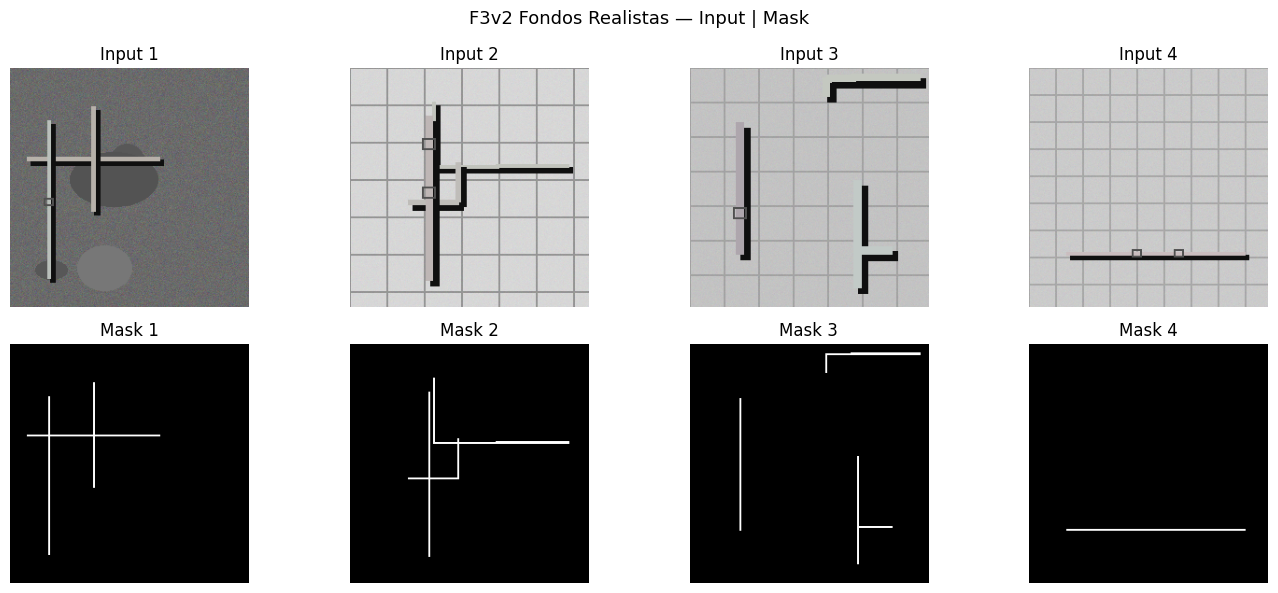

In [52]:
SUBFASE  = 'tuberias_fondos_reales'
FASE_DIR = os.path.join(DATASET_BASE, SUBFASE)

dir_input = os.path.join(FASE_DIR, 'train', 'inputs')
dir_mask  = os.path.join(FASE_DIR, 'train', 'masks')
muestras  = sorted(os.listdir(dir_input))[:4]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('F3v2 Fondos Realistas — Input | Mask', fontsize=13)

for col, nombre in enumerate(muestras):
    img  = Image.open(os.path.join(dir_input, nombre))
    mask = Image.open(os.path.join(dir_mask,  nombre))
    axes[0][col].imshow(img);               axes[0][col].set_title(f'Input {col+1}'); axes[0][col].axis('off')
    axes[1][col].imshow(mask, cmap='gray'); axes[1][col].set_title(f'Mask {col+1}');  axes[1][col].axis('off')

plt.tight_layout()
plt.show()

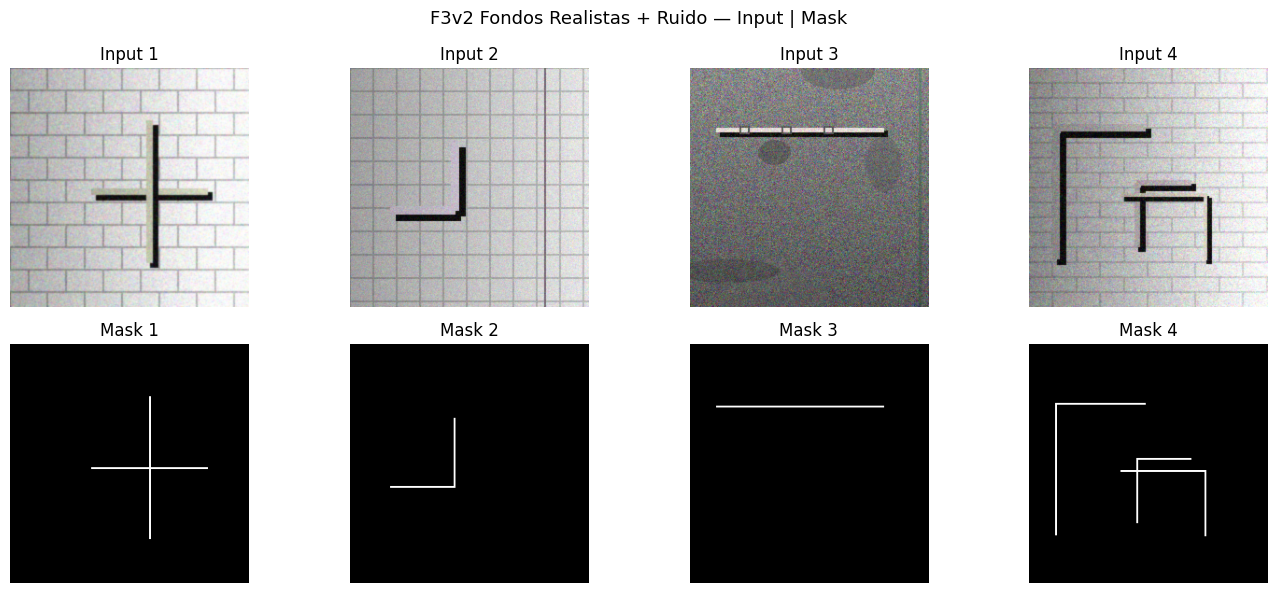

In [53]:
SUBFASE  = 'tuberias_fondos_con_ruido'
FASE_DIR = os.path.join(DATASET_BASE, SUBFASE)

dir_input = os.path.join(FASE_DIR, 'train', 'inputs')
dir_mask  = os.path.join(FASE_DIR, 'train', 'masks')
muestras  = sorted(os.listdir(dir_input))[:4]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('F3v2 Fondos Realistas + Ruido — Input | Mask', fontsize=13)

for col, nombre in enumerate(muestras):
    img  = Image.open(os.path.join(dir_input, nombre))
    mask = Image.open(os.path.join(dir_mask,  nombre))
    axes[0][col].imshow(img);               axes[0][col].set_title(f'Input {col+1}'); axes[0][col].axis('off')
    axes[1][col].imshow(mask, cmap='gray'); axes[1][col].set_title(f'Mask {col+1}');  axes[1][col].axis('off')

plt.tight_layout()
plt.show()

In [54]:
metadata = {
    'fase'     : 'fase3_v2_entrenamiento',
    'img_size' : IMG_SIZE,
    'train'    : TRAIN_N,
    'val'      : VAL_N,
    'test'     : TEST_N,
    'cambios_vs_f3_original': [
        'Fondos realistas: azulejo, ladrillo, concreto rugoso',
        'Color tuberías más cercano a PVC real',
        'Grosor reducido: 3-10px en vez de 4-12px',
        'Tubos de fondo más oscuros y de bajo contraste',
        'Ruido sobre fondos realistas'
    ],
    'fondos'   : ['azulejo', 'ladrillo', 'concreto_rugoso'],
    'elementos': ['tramo', 'codo', 'conexion_T', 'cruz', 'red'],
    'notas'    : 'F3v2 — fondos realistas para mejorar generalización a imágenes reales'
}

log_path = os.path.join(BASE, 'logs', 'fase3_v2_meta.json')
with open(log_path, 'w') as f:
    json.dump(metadata, f, indent=4)

total = (TRAIN_N + VAL_N + TEST_N) * 2
print(f"✅ Total generado fase3_v2:")
print(f"   Fondos realistas        : {TRAIN_N+VAL_N+TEST_N} imágenes")
print(f"   Fondos realistas + ruido: {TRAIN_N+VAL_N+TEST_N} imágenes")
print(f"   Total                   : {total} imágenes")
print(f"📋 Metadata guardada en logs/")

✅ Total generado fase3_v2:
   Fondos realistas        : 1400 imágenes
   Fondos realistas + ruido: 1400 imágenes
   Total                   : 2800 imágenes
📋 Metadata guardada en logs/
